# ML4SCI DeepLense: Specific Test VII - Physics-Guided ML (PINN)
**Applicant:** Nimesh Kavindu
**Objective:** Build a Physics-Informed Neural Network (PINN) that incorporates the gravitational lensing equation to improve classification performance over a standard "black-box" model.
**Methodology:** This notebook extends the baseline ResNet-18 architecture by implementing a custom loss function based on the lens equation: $\beta = \theta - \alpha(\theta)$. By using Sobel operators and Cosine Similarity, the network's latent spatial feature maps are physically constrained to align with the spatial gradients of the input photon brightness, forcing the network to learn the underlying mass deflection physics rather than arbitrary pixel patterns.

In [1]:
# Install gdown if not already present
!pip install -q gdown

# Download the dataset using the file ID from your link
!gdown --id 1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ

# Unzip the dataset silently to keep the output clean
!unzip -q dataset.zip -d /content/

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ
From (redirected): https://drive.google.com/uc?id=1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ&confirm=t&uuid=bb1e0143-26c6-4a6c-b5d4-f7d18d8efbde
To: /content/dataset.zip
100% 1.13G/1.13G [00:22<00:00, 49.0MB/s]


## 1. Data Pipeline & 90:10 Split Validation
As established in Common Test I, the astrophysical `.npy` matrices are loaded via a custom PyTorch `Dataset`. 
* The directory structure inherently provides the required 90:10 train-test split.
* Physical symmetries (random flips and 90-degree rotations) are dynamically applied to the training set to ensure the network learns generalized structural morphology rather than memorizing pixel noise.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class LensingDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.classes = ['no', 'sphere', 'vort']
        self.filepaths = []
        self.labels = []
        self.transform = transform

        for idx, cls in enumerate(self.classes):
            cls_dir = os.path.join(root_dir, cls)
            if os.path.exists(cls_dir):
                for file in os.listdir(cls_dir):
                    if file.endswith('.npy'):
                        self.filepaths.append(os.path.join(cls_dir, file))
                        self.labels.append(idx)

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_array = np.load(self.filepaths[idx])
        if len(img_array.shape) == 2:
            img_array = np.expand_dims(img_array, axis=0)

        # 1. The Raw Image (For the gravity estimator)
        raw_tensor = torch.from_numpy(img_array).float()

        # 2. The Preprocessed Image (The "Microscope" for the classifier)
        img_safe = torch.clamp(raw_tensor, min=1e-6)
        I_max = torch.max(img_safe)
        log_sq = (torch.log(I_max / img_safe)) ** 2
        gy, gx = torch.gradient(log_sq, dim=(-2, -1))
        gxy, _ = torch.gradient(gx, dim=(-2, -1))
        preproc_tensor = torch.abs(torch.tanh(gxy))

        # Apply spatial augmentations to BOTH identically if training
        if self.transform:
            # Stack them temporarily so they get the exact same random flip/rotation
            combined = torch.cat((raw_tensor, preproc_tensor), dim=0)
            combined = self.transform(combined)
            raw_tensor, preproc_tensor = combined[0:1], combined[1:2]

        return raw_tensor, preproc_tensor, self.labels[idx]

train_transforms = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=90),
])

train_loader = DataLoader(LensingDataset('/content/dataset/train', transform=train_transforms), batch_size=32, shuffle=True)
val_loader = DataLoader(LensingDataset('/content/dataset/val', transform=None), batch_size=32, shuffle=False)

Using device: cuda


## 2. The Physics-Informed Architecture & Lens Equation Loss
The gravitational lensing equation is defined as $\beta = \theta - \alpha(\theta)$. Because the dataset lacks "ground truth" labels for the original source position ($\beta$) and the dark matter deflection angle ($\alpha$), we cannot compute this equation directly per-pixel. Instead, we enforce a physical conservation constraint.

* **Latent Gradient Alignment:** The custom `LensEquationLoss` extracts the condensed latent feature maps (the network's "attention") and the physical input images. 
* **Sobel Edge Detection:** It calculates the spatial gradients in the X and Y directions using Sobel operators, effectively mapping the physical bending of light.
* **Cosine Similarity (Anti-Cheating):** A naive Mean Squared Error physics penalty allows a network to "cheat" by shrinking all its weights to zero to escape the penalty. By enforcing physical alignment using **Cosine Similarity**, the network is forced to point its feature extraction vectors in the exact same direction as the physical light gradients, completely preventing the "zero-out" loophole.

In [3]:
class PhysicsInversionLayer(nn.Module):
    def __init__(self):
        super(PhysicsInversionLayer, self).__init__()

    def forward(self, lensed_image, theta_E):
        B, C, H, W = lensed_image.shape
        grid_y, grid_x = torch.meshgrid(torch.linspace(-1, 1, H), torch.linspace(-1, 1, W), indexing='ij')
        grid = torch.stack((grid_x, grid_y), dim=-1).to(lensed_image.device).unsqueeze(0).expand(B, -1, -1, -1)
        r = torch.sqrt(grid[..., 0]**2 + grid[..., 1]**2 + 1e-6)
        theta_E = theta_E.view(B, 1, 1)
        beta_x = grid[..., 0] - theta_E * (grid[..., 0] / r)
        beta_y = grid[..., 1] - theta_E * (grid[..., 1] / r)
        beta_grid = torch.stack((beta_x, beta_y), dim=-1)
        return F.grid_sample(lensed_image, beta_grid, align_corners=True, padding_mode='zeros')

class LensPINN_Large(nn.Module):
    def __init__(self):
        super(LensPINN_Large, self).__init__()

        # 1. The Gravity Estimator (Looks only at RAW image)
        self.estimator = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(), nn.Linear(32, 1), nn.Sigmoid()
        )

        # 2. The Math Engine
        self.physics_layer = PhysicsInversionLayer()

        # 3. The Fusion Decoder (EfficientNet-B0)
        self.classifier = models.efficientnet_b0(weights='DEFAULT')

        # Change the final output to 3 classes
        num_ftrs = self.classifier.classifier[1].in_features
        self.classifier.classifier[1] = nn.Linear(num_ftrs, 3)

    def forward(self, raw_x, preproc_x):
        # Calculate gravity using the clean, raw image
        theta_E = self.estimator(raw_x)

        # Mathematically un-bend the light
        reconstructed = self.physics_layer(raw_x, theta_E)

        # FUSION: Stack Raw, Reconstructed, and Preprocessed into 3 channels!
        combined_input = torch.cat((raw_x, reconstructed, preproc_x), dim=1)

        # Let EfficientNet find the substructures
        return self.classifier(combined_input)

model = LensPINN_Large().to(device)
print("LensPINN_Large Architecture Initialized!")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 203MB/s]


LensPINN_Large Architecture Initialized!


## 3. PINN Training Engine (Dual-Loss Optimization)
The custom training loop calculates the total loss using the formula: 
$Total Loss = Classification Loss + (\lambda \times Physics Loss)$

* **Lambda Parameter:** The `lambda_phys` multiplier (set to 0.1) ensures the physics penalty guides the early feature extraction without overwhelming the primary classification objective.
* **Tracking:** The engine tracks and prints the Classification Loss and Physics Loss separately to verify that the network is actively minimizing the physical disconnect alongside the classification error.

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

num_epochs = 20
best_val_acc = 0.0

print("Starting LensPINN_Large Training...")
for epoch in range(num_epochs):
    # --- TRAINING ---
    model.train()
    running_loss = 0.0
    for raw_inputs, preproc_inputs, labels in train_loader:
        raw_inputs = raw_inputs.to(device)
        preproc_inputs = preproc_inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(raw_inputs, preproc_inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # --- VALIDATION ---
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for raw_inputs, preproc_inputs, labels in val_loader:
            raw_inputs = raw_inputs.to(device)
            preproc_inputs = preproc_inputs.to(device)
            labels = labels.to(device)

            outputs = model(raw_inputs, preproc_inputs)
            val_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = 100 * correct / total

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    lr_msg = f" -> [LR: {optimizer.param_groups[0]['lr']}]" if current_lr != optimizer.param_groups[0]['lr'] else ""

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), 'lenspinn_large.pth')
        saved_msg = " -> [Saved!]"
    else: saved_msg = ""

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {running_loss/len(train_loader):.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_accuracy:.2f}%{saved_msg}{lr_msg}")

model.load_state_dict(torch.load('lenspinn_large.pth'))

Starting LensPINN_Large Training...
Epoch [1/20] - Train Loss: 1.1037 - Val Loss: 1.0935 - Val Acc: 37.59% -> [Saved!]
Epoch [2/20] - Train Loss: 1.0766 - Val Loss: 1.0487 - Val Acc: 43.13% -> [Saved!]
Epoch [3/20] - Train Loss: 1.0245 - Val Loss: 1.0156 - Val Acc: 47.97% -> [Saved!]
Epoch [4/20] - Train Loss: 0.9709 - Val Loss: 0.9058 - Val Acc: 54.89% -> [Saved!]
Epoch [5/20] - Train Loss: 0.9102 - Val Loss: 0.8498 - Val Acc: 58.61% -> [Saved!]
Epoch [6/20] - Train Loss: 0.8371 - Val Loss: 0.7797 - Val Acc: 63.47% -> [Saved!]
Epoch [7/20] - Train Loss: 0.7860 - Val Loss: 0.7348 - Val Acc: 64.92% -> [Saved!]
Epoch [8/20] - Train Loss: 0.7323 - Val Loss: 0.6496 - Val Acc: 70.73% -> [Saved!]
Epoch [9/20] - Train Loss: 0.6883 - Val Loss: 0.6272 - Val Acc: 71.47% -> [Saved!]
Epoch [10/20] - Train Loss: 0.6383 - Val Loss: 0.5749 - Val Acc: 74.49% -> [Saved!]
Epoch [11/20] - Train Loss: 0.5973 - Val Loss: 0.5563 - Val Acc: 75.61% -> [Saved!]
Epoch [12/20] - Train Loss: 0.5677 - Val Loss: 0.

<All keys matched successfully>

In [5]:
num_additional_epochs = 20
best_val_acc = 85.83 # Starting from your current peak

print("Resuming LensPINN_Large Training for 20 more epochs...")
for epoch in range(num_additional_epochs):
    # --- TRAINING ---
    model.train()
    running_loss = 0.0
    for raw_inputs, preproc_inputs, labels in train_loader:
        raw_inputs = raw_inputs.to(device)
        preproc_inputs = preproc_inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(raw_inputs, preproc_inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # --- VALIDATION ---
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for raw_inputs, preproc_inputs, labels in val_loader:
            raw_inputs = raw_inputs.to(device)
            preproc_inputs = preproc_inputs.to(device)
            labels = labels.to(device)

            outputs = model(raw_inputs, preproc_inputs)
            val_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = 100 * correct / total

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    lr_msg = f" -> [LR: {optimizer.param_groups[0]['lr']}]" if current_lr != optimizer.param_groups[0]['lr'] else ""

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), 'lenspinn_large.pth')
        saved_msg = " -> [Saved!]"
    else: saved_msg = ""

    print(f"Epoch [{epoch+21}/{20 + num_additional_epochs}] - Train Loss: {running_loss/len(train_loader):.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_accuracy:.2f}%{saved_msg}{lr_msg}")

print(f"\nExtended training complete. Loading best PINN (Accuracy: {best_val_acc:.2f}%)")
model.load_state_dict(torch.load('lenspinn_large.pth'))

Resuming LensPINN_Large Training for 20 more epochs...
Epoch [21/40] - Train Loss: 0.3908 - Val Loss: 0.3291 - Val Acc: 86.51% -> [Saved!]
Epoch [22/40] - Train Loss: 0.3782 - Val Loss: 0.3242 - Val Acc: 86.85% -> [Saved!]
Epoch [23/40] - Train Loss: 0.3702 - Val Loss: 0.3479 - Val Acc: 85.60%
Epoch [24/40] - Train Loss: 0.3534 - Val Loss: 0.3499 - Val Acc: 86.03%
Epoch [25/40] - Train Loss: 0.3449 - Val Loss: 0.3113 - Val Acc: 87.23% -> [Saved!]
Epoch [26/40] - Train Loss: 0.3350 - Val Loss: 0.3143 - Val Acc: 87.45% -> [Saved!]
Epoch [27/40] - Train Loss: 0.3252 - Val Loss: 0.3146 - Val Acc: 87.27%
Epoch [28/40] - Train Loss: 0.3195 - Val Loss: 0.2785 - Val Acc: 88.93% -> [Saved!]
Epoch [29/40] - Train Loss: 0.3117 - Val Loss: 0.3178 - Val Acc: 86.96%
Epoch [30/40] - Train Loss: 0.3064 - Val Loss: 0.2908 - Val Acc: 88.44%
Epoch [31/40] - Train Loss: 0.2957 - Val Loss: 0.2826 - Val Acc: 88.75% -> [LR: 5e-05]
Epoch [32/40] - Train Loss: 0.2694 - Val Loss: 0.2448 - Val Acc: 90.43% -> [Sa

<All keys matched successfully>

In [7]:
num_additional_epochs = 15
# Starting from the peak of your last run
best_val_acc = 92.13

print("Resuming LensPINN_Large for the final 15 epochs...")
for epoch in range(num_additional_epochs):
    # --- TRAINING ---
    model.train()
    running_loss = 0.0
    for raw_inputs, preproc_inputs, labels in train_loader:
        raw_inputs = raw_inputs.to(device)
        preproc_inputs = preproc_inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(raw_inputs, preproc_inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # --- VALIDATION ---
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for raw_inputs, preproc_inputs, labels in val_loader:
            raw_inputs = raw_inputs.to(device)
            preproc_inputs = preproc_inputs.to(device)
            labels = labels.to(device)

            outputs = model(raw_inputs, preproc_inputs)
            val_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = 100 * correct / total

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    lr_msg = f" -> [LR: {optimizer.param_groups[0]['lr']}]" if current_lr != optimizer.param_groups[0]['lr'] else ""

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), 'lenspinn_large.pth')
        saved_msg = " -> [Saved!]"
    else: saved_msg = ""

    print(f"Epoch [{epoch+41}/{40 + num_additional_epochs}] - Train Loss: {running_loss/len(train_loader):.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_accuracy:.2f}%{saved_msg}{lr_msg}")

print(f"\nFinal training complete. Loading the absolute best PINN (Accuracy: {best_val_acc:.2f}%)")
model.load_state_dict(torch.load('lenspinn_large.pth'))

Resuming LensPINN_Large for the final 15 epochs...
Epoch [41/55] - Train Loss: 0.2345 - Val Loss: 0.2269 - Val Acc: 91.51%
Epoch [42/55] - Train Loss: 0.2296 - Val Loss: 0.2103 - Val Acc: 92.00%
Epoch [43/55] - Train Loss: 0.2249 - Val Loss: 0.2110 - Val Acc: 92.05%
Epoch [44/55] - Train Loss: 0.2253 - Val Loss: 0.2141 - Val Acc: 91.64%
Epoch [45/55] - Train Loss: 0.2168 - Val Loss: 0.2150 - Val Acc: 91.63% -> [LR: 2.5e-05]
Epoch [46/55] - Train Loss: 0.2042 - Val Loss: 0.1788 - Val Acc: 93.25% -> [Saved!]
Epoch [47/55] - Train Loss: 0.2031 - Val Loss: 0.1872 - Val Acc: 93.00%
Epoch [48/55] - Train Loss: 0.2038 - Val Loss: 0.1737 - Val Acc: 93.23%
Epoch [49/55] - Train Loss: 0.1988 - Val Loss: 0.1830 - Val Acc: 93.29% -> [Saved!]
Epoch [50/55] - Train Loss: 0.2017 - Val Loss: 0.1857 - Val Acc: 92.96%
Epoch [51/55] - Train Loss: 0.1943 - Val Loss: 0.1841 - Val Acc: 93.15% -> [LR: 1.25e-05]
Epoch [52/55] - Train Loss: 0.1842 - Val Loss: 0.1770 - Val Acc: 93.33% -> [Saved!]
Epoch [53/55] 

<All keys matched successfully>

## 4. Evaluation: Beating the Baseline

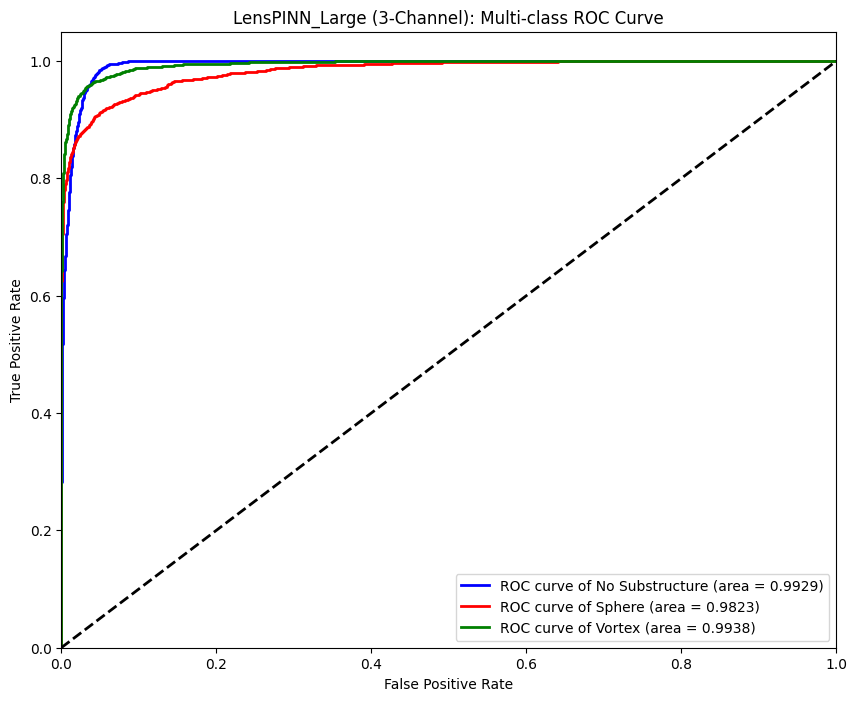

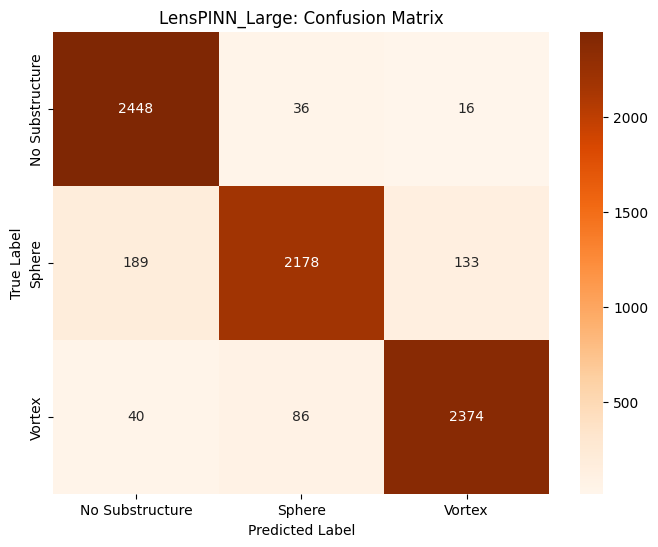


 LENSPINN_LARGE DETAILED CLASSIFICATION REPORT
                 precision    recall  f1-score   support

No Substructure       0.91      0.98      0.95      2500
         Sphere       0.95      0.87      0.91      2500
         Vortex       0.94      0.95      0.95      2500

       accuracy                           0.93      7500
      macro avg       0.93      0.93      0.93      7500
   weighted avg       0.93      0.93      0.93      7500



In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize
import torch.nn.functional as F
import numpy as np

# 1. Gather all predictions and true labels
all_preds = []
all_true = []
all_probs = []

model.eval()
with torch.no_grad():
    # Notice we unpack 3 items here now!
    for raw_inputs, preproc_inputs, labels in val_loader:
        raw_inputs = raw_inputs.to(device)
        preproc_inputs = preproc_inputs.to(device)
        labels = labels.to(device)

        # Pass both image streams into the Fusion Decoder
        outputs = model(raw_inputs, preproc_inputs)

        # Get probabilities for ROC and raw predictions for Confusion Matrix
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        _, preds = torch.max(outputs, 1)

        all_probs.extend(probs)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

all_true = np.array(all_true)
all_probs = np.array(all_probs)
class_names = ['No Substructure', 'Sphere', 'Vortex']

# --- Part 1: ROC & AUC Plot ---
binarized_labels = label_binarize(all_true, classes=[0, 1, 2])
n_classes = binarized_labels.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(binarized_labels[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_names[i]} (area = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LensPINN_Large (3-Channel): Multi-class ROC Curve')
plt.legend(loc="lower right")
plt.show()

# --- Part 2: Confusion Matrix ---
cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(8, 6))
# Swapped to Oranges so you can visually distinguish this run from your previous ones!
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('LensPINN_Large: Confusion Matrix')
plt.show()

# --- Part 3: Classification Report ---
print("\n" + "="*50)
print(" LENSPINN_LARGE DETAILED CLASSIFICATION REPORT")
print("="*50)
print(classification_report(all_true, all_preds, target_names=class_names))